In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.base import clone

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

In [3]:
pd.set_option('display.max_columns', None)
X_train = pd.read_csv('data/train05_apache_only.csv')
y_train = pd.read_csv('data/Ytrain05.csv').squeeze()
X_test = pd.read_csv('data/test_apache_only.csv')
y_test = pd.read_csv('data/y_test.csv').squeeze()
X_train.head(5)

,albumin_apache,apache_post_operative,arf_apache,bilirubin_apache,bun_apache,creatinine_apache,fio2_apache,gcs_eyes_apache,gcs_motor_apache,gcs_unable_apache,gcs_verbal_apache,glucose_apache,heart_rate_apache,hematocrit_apache,intubated_apache,map_apache,paco2_apache,pao2_apache,ph_apache,resprate_apache,sodium_apache,temp_apache,urineoutput_apache,ventilated_apache,wbc_apache,apache_3j_bodysystem_Cardiovascular,apache_3j_bodysystem_Gastrointestinal,apache_3j_bodysystem_Genitourinary,apache_3j_bodysystem_Gynecological,apache_3j_bodysystem_Hematological,apache_3j_bodysystem_Metabolic,apache_3j_bodysystem_Musculoskeletal/Skin,apache_3j_bodysystem_Neurological,apache_3j_bodysystem_Respiratory,apache_3j_bodysystem_Sepsis,apache_3j_bodysystem_Trauma,apache_3j_bodysystem_missing,apache_2_diagnosis,age,pre_icu_los_days,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis
0,3.1,0.0,1.0,0.7,59.0,5.70,0.5,4.0,6.0,0.0,5.0,296.0,54.0,29.0,0.0,56.0,40.0,103.0,7.360,12.0,137.0,36.6,1387.2384,0.0,7.26,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.040728,76.0,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.9,0.0,0.0,0.7,17.0,0.80,0.5,4.0,6.0,0.0,5.0,107.0,47.0,36.6,0.0,137.0,40.0,103.0,7.360,26.0,136.0,36.6,3067.2864,0.0,7.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.075170,79.0,0.078472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.5,0.0,0.0,0.9,14.0,0.50,0.5,4.0,6.0,0.0,5.0,190.0,119.0,37.1,0.0,163.0,40.0,103.0,7.360,15.0,136.0,37.7,2065.1328,0.0,34.14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.075170,55.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.8,1.0,0.0,0.3,12.0,0.70,0.3,1.0,5.0,0.0,1.0,167.0,96.0,31.7,1.0,75.0,35.0,135.0,7.381,14.0,137.0,34.5,1387.2384,1.0,19.70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.145393,44.0,0.194444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2.9,1.0,0.0,0.7,8.0,0.67,0.5,3.0,6.0,0.0,5.0,137.0,91.0,30.1,0.0,107.0,40.0,103.0,7.360,7.0,139.0,37.4,1387.2384,0.0,10.80,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.046851,28.0,1.197917,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
xgb = XGBClassifier(random_state = 24, eval_metric = 'logloss')

xgb.fit(X_train, y_train)

y_proba = xgb.predict_proba(X_test)[:,1]
y_pred = xgb.predict(X_test)

Accuracy: 84.23%
Recall: 64.55%
Precision: 30.95%
F1: 41.84%


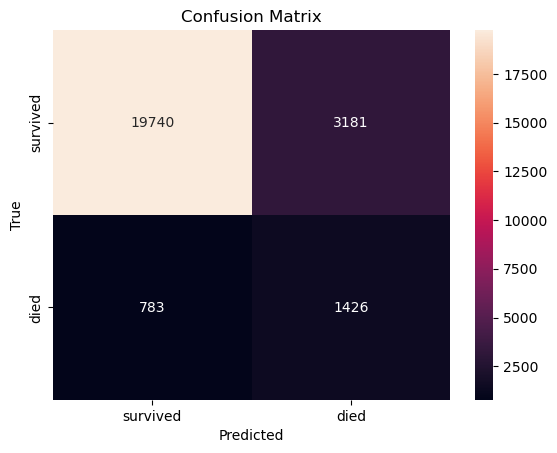

In [5]:
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('Accuracy: %.2f%%' % (accuracy * 100.0))
print('Recall: %.2f%%' % (recall * 100.0))
print('Precision: %.2f%%' % (precision * 100.0))
print('F1: %.2f%%' % (f1 * 100.0))

matrix = confusion_matrix(y_test, y_pred)
ax = plt.subplot()
sns.heatmap(matrix, annot = True, fmt = 'g', ax = ax);

ax.set_xlabel('Predicted');ax.set_ylabel('True');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(['survived', 'died']);
ax.yaxis.set_ticklabels(['survived', 'died']);

In [6]:
matrix

array([[19740,  3181],
       [  783,  1426]])

AUC: 0.8427086805864906


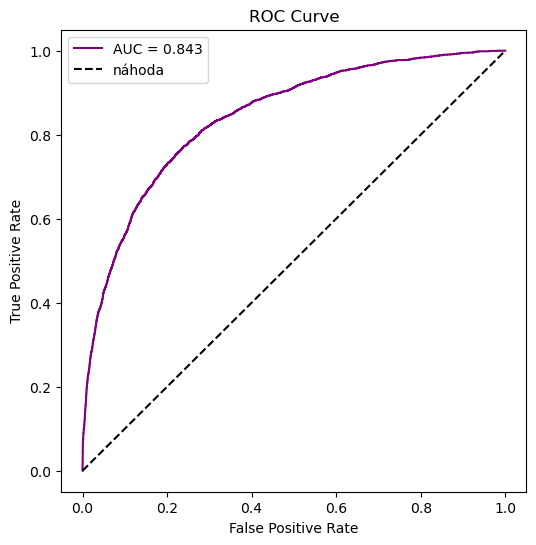

In [7]:
auc = roc_auc_score(y_test, y_proba)
print("AUC:", auc)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color = 'purple')
plt.plot([0,1], [0,1], 'k--', label='náhoda')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()